# 02 Regime Maps

## Why This Notebook Exists
The strategy is path-dependent. This notebook labels each day by rolling drift, volatility, and autocorrelation so you can see where returns are structurally strong or weak.

## What You Should Get
- Heatmaps of mean return and Sharpe by (`mu_bin`, `vol_bin`).
- Regime counts to identify sample-coverage bias.
- Drift-vol scatter plots colored by strategy return.


In [9]:
# Standard notebook bootstrap.
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.experiments.run_regimes import run as run_regimes
from src.utils.io import load_config


## Controls
- Change `CONFIG_PATH` to run a single pair config for faster iteration.
- Regime lookbacks and quantiles are set under `regimes.*` in YAML.


In [10]:
CONFIG_PATH = ROOT / "configs" / "default.yaml"
cfg = load_config(CONFIG_PATH)

# run_regimes generates labeled outputs and writes regime tables/figures to reports/.
labeled_by_pair = run_regimes(str(CONFIG_PATH))
print("Regimes generated for:", list(labeled_by_pair.keys()))


Regimes generated for: ['btc_bitx', 'qqq_tqqq']


## Regime Label Definitions
- `mu_bin` (heatmap **y-axis**): rolling drift quantile bucket.
- `vol_bin` (heatmap **x-axis**): rolling volatility quantile bucket.
- `regime_2d`: direction x volatility coarse label.
- `regime_3d`: direction x volatility x autocorrelation label.
- Quartile key used in axis labels:
  - `Q1` = lowest quartile (0-25%)
  - `Q2` = second quartile (25-50%)
  - `Q3` = third quartile (50-75%)
  - `Q4` = highest quartile (75-100%)


In [11]:
# Coverage check: low-count bins can make heatmaps noisy.
for name, df in labeled_by_pair.items():
    print(f"\n{name}: regime_2d counts")
    display(df["regime_2d"].value_counts().to_frame("count"))
    print(f"{name}: regime_3d counts (top 10)")
    display(df["regime_3d"].value_counts().head(10).to_frame("count"))

    # Numeric key for quartile bins used on heatmap axes.
    mu_key = (
        df.groupby("mu_bin", observed=False)["drift"]
        .agg(lower_bound="min", upper_bound="max", n_obs="count")
        .reset_index()
    )
    vol_key = (
        df.groupby("vol_bin", observed=False)["vol"]
        .agg(lower_bound="min", upper_bound="max", n_obs="count")
        .reset_index()
    )
    print(f"{name}: mu_bin key (y-axis / drift)")
    display(mu_key)
    print(f"{name}: vol_bin key (x-axis / volatility)")
    display(vol_key)



btc_bitx: regime_2d counts


,count
regime_2d,
up_high_vol,230
down_low_vol,229
up_low_vol,225
down_high_vol,225


btc_bitx: regime_3d counts (top 10)


,count
regime_3d,
down_high_vol_neg_rho,173
up_high_vol_neg_rho,157
down_low_vol_neg_rho,137
up_low_vol_pos_rho,125
up_low_vol_neg_rho,100
down_low_vol_pos_rho,92
up_high_vol_pos_rho,73
down_high_vol_pos_rho,52


btc_bitx: mu_bin key (y-axis / drift)


...

,count
regime_3d,
down_high_vol_neg_rho,279
up_low_vol_pos_rho,217
up_low_vol_neg_rho,213
down_high_vol_pos_rho,151
up_high_vol_neg_rho,129
down_low_vol_neg_rho,109
down_low_vol_pos_rho,100
up_high_vol_pos_rho,81


qqq_tqqq: mu_bin key (y-axis / drift)


,mu_bin,lower_bound,upper_bound,n_obs
0,Q1,-1.856202,-0.149290,320
1,Q2,-0.149223,0.238657,320
2,Q3,0.239296,0.526242,319
3,Q4,0.527982,1.969188,320


qqq_tqqq: vol_bin key (x-axis / volatility)


,vol_bin,lower_bound,upper_bound,n_obs
0,Q1,0.084420,0.149410,320
1,Q2,0.149503,0.177379,320
2,Q3,0.177551,0.245821,319
3,Q4,0.246540,0.510421,320


In [12]:
def plot_heatmap(
    df: pd.DataFrame,
    title: str,
    cmap: str = "RdYlBu_r",
    colorbar_label: str = "Value",
):
    """Draw a compact annotated heatmap for regime summary tables."""
    vals = df.values.astype(float)
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(vals, cmap=cmap, aspect="auto")
    ax.set_xticks(range(df.shape[1]))
    ax.set_yticks(range(df.shape[0]))
    ax.set_xticklabels(df.columns)
    ax.set_yticklabels(df.index)
    ax.set_title(title)
    ax.set_xlabel("Volatility Quantile Bin (vol_bin)")
    ax.set_ylabel("Drift Quantile Bin (mu_bin)")

    # Print numeric values so users can read exact bins without exporting CSVs.
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            if np.isfinite(vals[i, j]):
                ax.text(j, i, f"{vals[i, j]:.4f}", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)
    fig.text(
        0.5,
        0.01,
        "Key: Q1=lowest quartile, Q2=25-50%, Q3=50-75%, Q4=highest quartile",
        ha="center",
        fontsize=9,
    )
    plt.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()


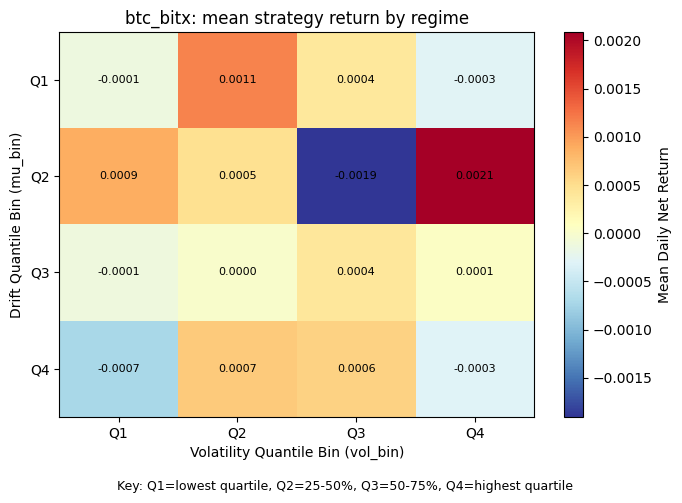

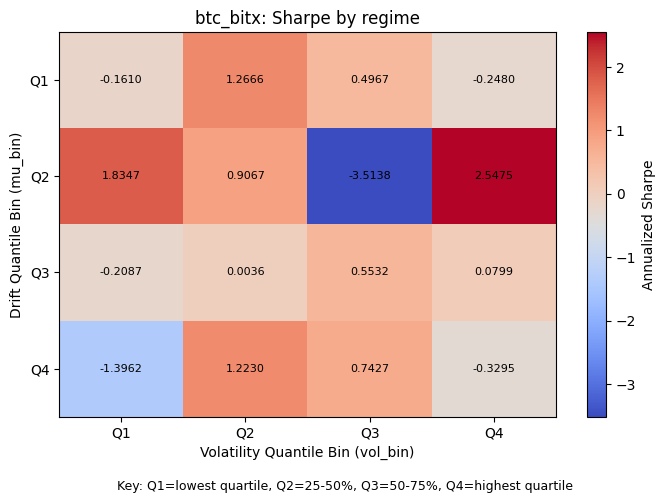

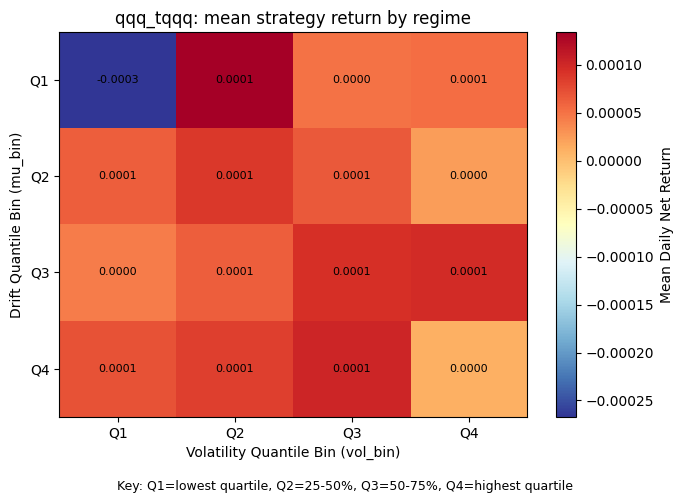

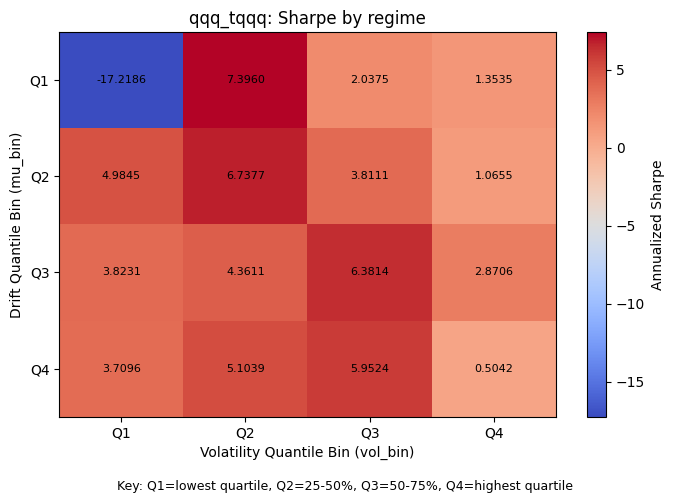

In [13]:
# Build mean-return and Sharpe maps for each pair.
for name, df in labeled_by_pair.items():
    mean_map = df.pivot_table(
        index="mu_bin",
        columns="vol_bin",
        values="net_ret",
        aggfunc="mean",
        observed=False,
    )

    sharpe_map = df.groupby(["mu_bin", "vol_bin"], observed=False)["net_ret"].apply(
        lambda s: (s.mean() / s.std()) * np.sqrt(252) if s.std() > 0 else np.nan
    ).unstack()

    plot_heatmap(
        mean_map,
        f"{name}: mean strategy return by regime",
        colorbar_label="Mean Daily Net Return",
    )
    plot_heatmap(
        sharpe_map,
        f"{name}: Sharpe by regime",
        cmap="coolwarm",
        colorbar_label="Annualized Sharpe",
    )


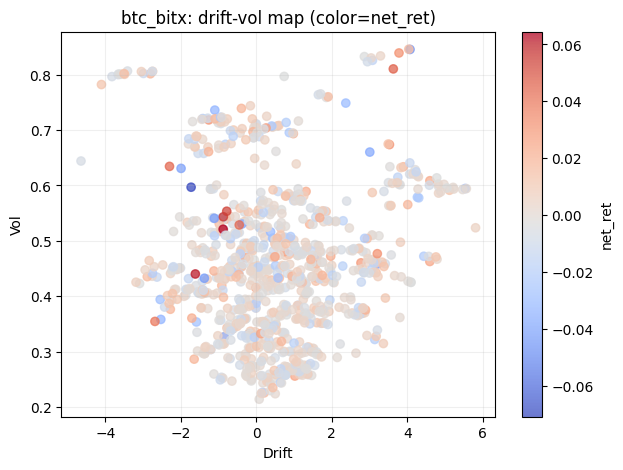

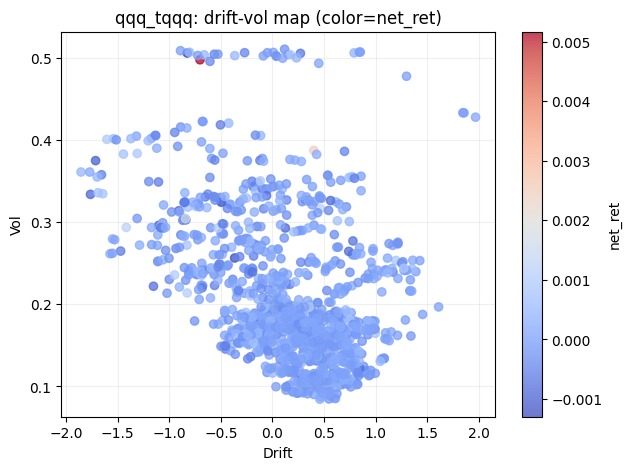

In [14]:
# Scatter view: useful for spotting failure clusters in high-drift/high-vol corners.
for name, df in labeled_by_pair.items():
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(df["drift"], df["vol"], c=df["net_ret"], cmap="coolwarm", alpha=0.75)
    ax.set_title(f"{name}: drift-vol map (color=net_ret)")
    ax.set_xlabel("Drift")
    ax.set_ylabel("Vol")
    ax.grid(alpha=0.2)
    fig.colorbar(sc, ax=ax, label="net_ret")
    plt.show()


In [15]:
# Optional quick summary: fraction of positive days per 2D bin.
for name, df in labeled_by_pair.items():
    positive_rate = df.assign(pos=(df["net_ret"] > 0).astype(int)).groupby(
        ["mu_bin", "vol_bin"], observed=False
    )["pos"].mean().unstack()
    print(f"\n{name}: positive-day rate by bin")
    display(positive_rate)



btc_bitx: positive-day rate by bin


vol_bin,Q1,Q2,Q3,Q4
mu_bin,,,,
Q1,0.461538,0.555556,0.461538,0.486486
Q2,0.512195,0.586957,0.438596,0.595238
Q3,0.562500,0.500000,0.557692,0.486486
Q4,0.518519,0.516667,0.545455,0.486486



qqq_tqqq: positive-day rate by bin


vol_bin,Q1,Q2,Q3,Q4
mu_bin,,,,
Q1,0.222222,0.632653,0.517647,0.502825
Q2,0.630769,0.632184,0.607143,0.535714
Q3,0.622047,0.614679,0.591837,0.529412
Q4,0.588235,0.653333,0.630137,0.566038


In [16]:
# Output integrity checks.
for name, df in labeled_by_pair.items():
    needed = ["regime_2d", "regime_3d", "mu_bin", "vol_bin", "net_ret"]
    assert set(needed).issubset(df.columns), f"{name}: missing regime columns"
    assert df["regime_2d"].notna().all(), f"{name}: regime_2d has missing labels"
    assert df["mu_bin"].notna().all(), f"{name}: mu_bin has missing labels"
    assert df["vol_bin"].notna().all(), f"{name}: vol_bin has missing labels"

print("Regime checks passed.")


Regime checks passed.


## Next Notebook
Proceed to `03_stress_tests.ipynb` to evaluate realized crisis windows and Monte Carlo tail behavior under current strategy rules.
